# Nadie sabe cómo los mismos perros cruzaron toda Europa

**3,188 km.** Eso separa una cueva en Inglaterra de un asentamiento en Turquía. Hace 14,000 años, en ambos sitios vivían perros genéticamente casi idénticos. ¿Cómo llegaron tan lejos sin aviones, barcos ni carreteras?

---

**Paper:** Scarsbrook, L. et al. (2026). "A genetically homogeneous dog population in the Late Upper Palaeolithic." *Nature*.
**DOI:** [10.1038/s41586-026-10170-x](https://doi.org/10.1038/s41586-026-10170-x)
**Video:** [Ver en YouTube](https://youtube.com/watch?v=62WFFzEFzNM)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-04-01-perros-cruzaron-europa/notebook.ipynb)

## ¿Qué hicieron?

Extrajeron ADN de huesos de perros y lobos antiguos — desde Pınarbaşı (Turquía, 15.800 años) y Gough's Cave (Reino Unido, 14.300 años) hasta sitios mesolíticos en Serbia. En total tenemos 148 muestras antiguas — 74 perros, 73 lobos y 1 dhole — de 25 países.

Todo apunta a que para hace 14.300 años ya existía una población de perros genéticamente homogénea repartida desde las islas británicas hasta Anatolia. Eso significa que tres culturas humanas completamente distintas — los magdalenienses, los epigravettinos y los cazadores-recolectores de Anatolia — compartían los mismos perros.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
UMBRAL_ANTIGUO = 14300       # Años BP: perros ya distribuidos por Europa
DISTANCIA_UK_TURQUIA = 3188  # km entre Gough's Cave y Pınarbaşı
FUENTE = 'Fuente: Scarsbrook et al. (2026), Nature | Datos: Supplementary Tables'
COLOR_PERRO = '#2563EB'
COLOR_LOBO = '#DC2626'
COLOR_NUEVO = '#D97706'
COLOR_ARCTIC = '#059669'
COLOR_HIGHLIGHT = '#7C3AED'

# ── Imports y estilo ──
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, urllib.request, re

BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

# ── Datos ──
for f in ['muestras.csv', 'cronologia.csv', 'isotopos.csv']:
    if not os.path.exists(f'datos/{f}'):
        os.makedirs('datos', exist_ok=True)
        urllib.request.urlretrieve(f'{BASE}/papers/2026-04-01-perros-cruzaron-europa/datos/{f}', f'datos/{f}')

muestras = pd.read_csv('datos/muestras.csv')
cronologia = pd.read_csv('datos/cronologia.csv')
isotopos = pd.read_csv('datos/isotopos.csv')

# Parsear edades (algunas son rangos como "c.11500-8300")
def parse_age(val):
    if pd.isna(val):
        return np.nan
    s = str(val).strip().replace('c.', '').replace('c', '').strip()
    m = re.match(r'(\d+)\s*[-–]\s*(\d+)', s)
    if m:
        return (float(m.group(1)) + float(m.group(2))) / 2
    m = re.match(r'^(\d+\.?\d*)$', s)
    if m:
        return float(m.group(1))
    return np.nan

muestras['age_parsed'] = muestras['age_bp'].apply(parse_age)
muestras['best_age'] = muestras['calibrated_age_bp'].fillna(muestras['age_parsed'])

dogs = muestras[muestras['species'] == 'Dog'].copy()
wolves = muestras[muestras['species'] == 'Wolf'].copy()

print(f"Muestras antiguas: {len(muestras)} ({len(dogs)} perros, {len(wolves)} lobos, {len(muestras) - len(dogs) - len(wolves)} otros)")
print(f"Países: {muestras['country'].nunique()}")
print(f"Perro más antiguo: {dogs['best_age'].max():.0f} BP (Pınarbaşı, Turquía)")
print(f"Cronología completa: {len(cronologia)} entradas de {cronologia['paper'].nunique()} estudios")

Muestras antiguas: 148 (74 perros, 73 lobos, 1 otros)
Países: 25
Perro más antiguo: 15787 BP (Pınarbaşı, Turquía)
Cronología completa: 240 entradas de 26 estudios


## El mapa de los perros más antiguos del mundo

Aquí está.

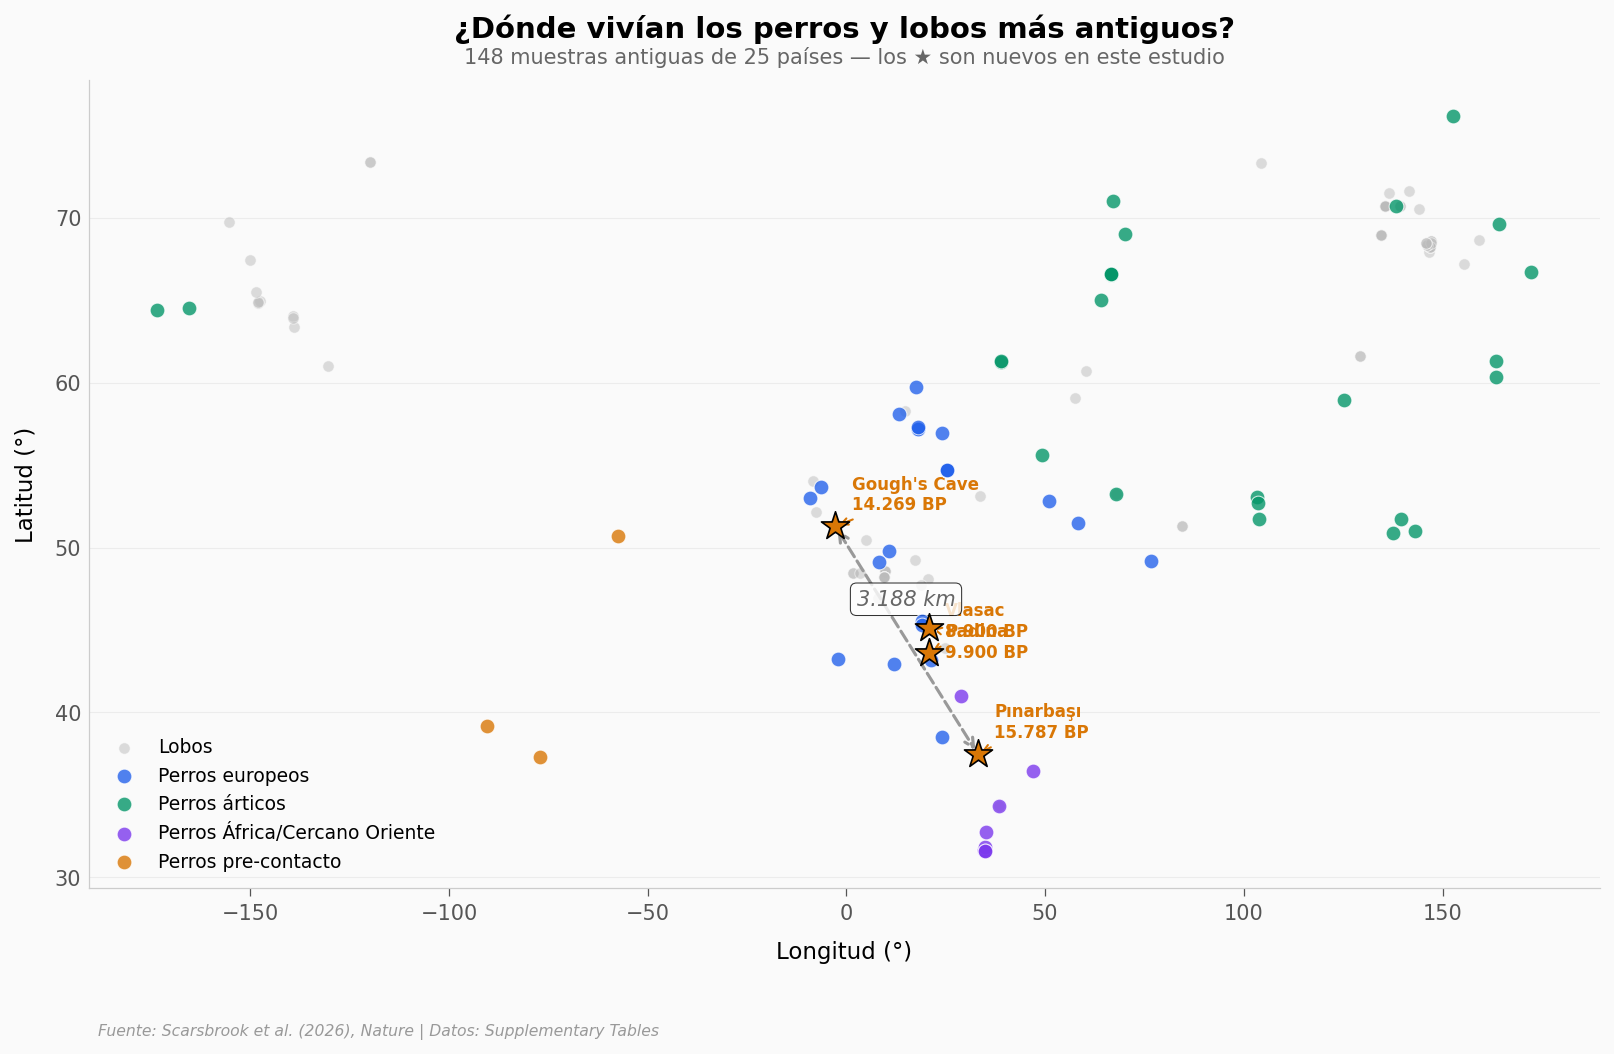

In [2]:
fig, ax = plt.subplots(figsize=(13, 7))

# Fondo: todos los lobos (gris)
wolves_coords = wolves.dropna(subset=['lat', 'lon'])
ax.scatter(wolves_coords['lon'], wolves_coords['lat'],
           c='#BBBBBB', s=30, alpha=0.5, edgecolors='white',
           linewidths=0.5, zorder=3, label='Lobos')

# Perros por grupo
groups_colors = {
    'Ancient_European_Dogs': (COLOR_PERRO, 'Perros europeos'),
    'Ancient_Arctic_Dogs': (COLOR_ARCTIC, 'Perros árticos'),
    'Ancient_African_NearEast_India_Dogs': (COLOR_HIGHLIGHT, 'Perros África/Cercano Oriente'),
    'Ancient_preContact_Dogs': ('#D97706', 'Perros pre-contacto'),
}
for grp, (color, label) in groups_colors.items():
    sub = dogs[(dogs['group'] == grp)].dropna(subset=['lat', 'lon'])
    ax.scatter(sub['lon'], sub['lat'], c=color, s=50, alpha=0.8,
               edgecolors='white', linewidths=0.5, zorder=4, label=label)

# Destacar los 4 sitios nuevos
new_sites = {
    'Pınarbaşı': (33.02, 37.49, 15787),
    "Gough's Cave": (-2.77, 51.28, 14269),
    'Padina': (20.72, 45.12, 9900),
    'Vlasac': (20.72, 43.60, 8900),
}
for name, (lon, lat, age) in new_sites.items():
    ax.scatter(lon, lat, c=COLOR_NUEVO, s=200, marker='*', zorder=6,
               edgecolors='black', linewidths=0.8)
    offset = (8, 8) if name != 'Padina' else (8, -14)
    ax.annotate(f'{name}\n{age:,} BP'.replace(',', '.'),
                xy=(lon, lat), xytext=offset, textcoords='offset points',
                fontsize=8, fontweight='bold', color=COLOR_NUEVO,
                arrowprops=dict(arrowstyle='->', color=COLOR_NUEVO, lw=1))

# Línea conectando UK ↔ Turquía
ax.annotate('', xy=(33.02, 37.49), xytext=(-2.77, 51.28),
            arrowprops=dict(arrowstyle='<->', color='#999999', lw=1.5, ls='--'))
ax.text(15, 46.5, f'{DISTANCIA_UK_TURQUIA:,} km'.replace(',', '.'),
        fontsize=10, color='#666666', ha='center', style='italic',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

ax.set_xlabel('Longitud (°)', fontsize=11)
ax.set_ylabel('Latitud (°)', fontsize=11)
ax.set_title('¿Dónde vivían los perros y lobos más antiguos?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, f'{len(muestras)} muestras antiguas de {muestras["country"].nunique()} países — los ★ son nuevos en este estudio',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.legend(fontsize=9, loc='lower left', framealpha=0.9)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/mapa_muestras.png', dpi=200, bbox_inches='tight')
plt.show()

Lo que llama la atención: una línea punteada conecta Gough's Cave (Inglaterra) con Pınarbaşı (Turquía) — **3.188 km de distancia**. Hace más de 14.000 años, en ambos sitios los perros eran genéticamente casi iguales. Y eso que los humanos de cada sitio pertenecían a culturas completamente distintas.

Los datos sugieren que los perros se movían — o eran intercambiados — entre grupos humanos que no compartían ni lengua ni tecnología.

## ¿Cuándo aparecen los perros más antiguos?

Veamos la cronología completa: 59 perros datados de 11 estudios distintos.

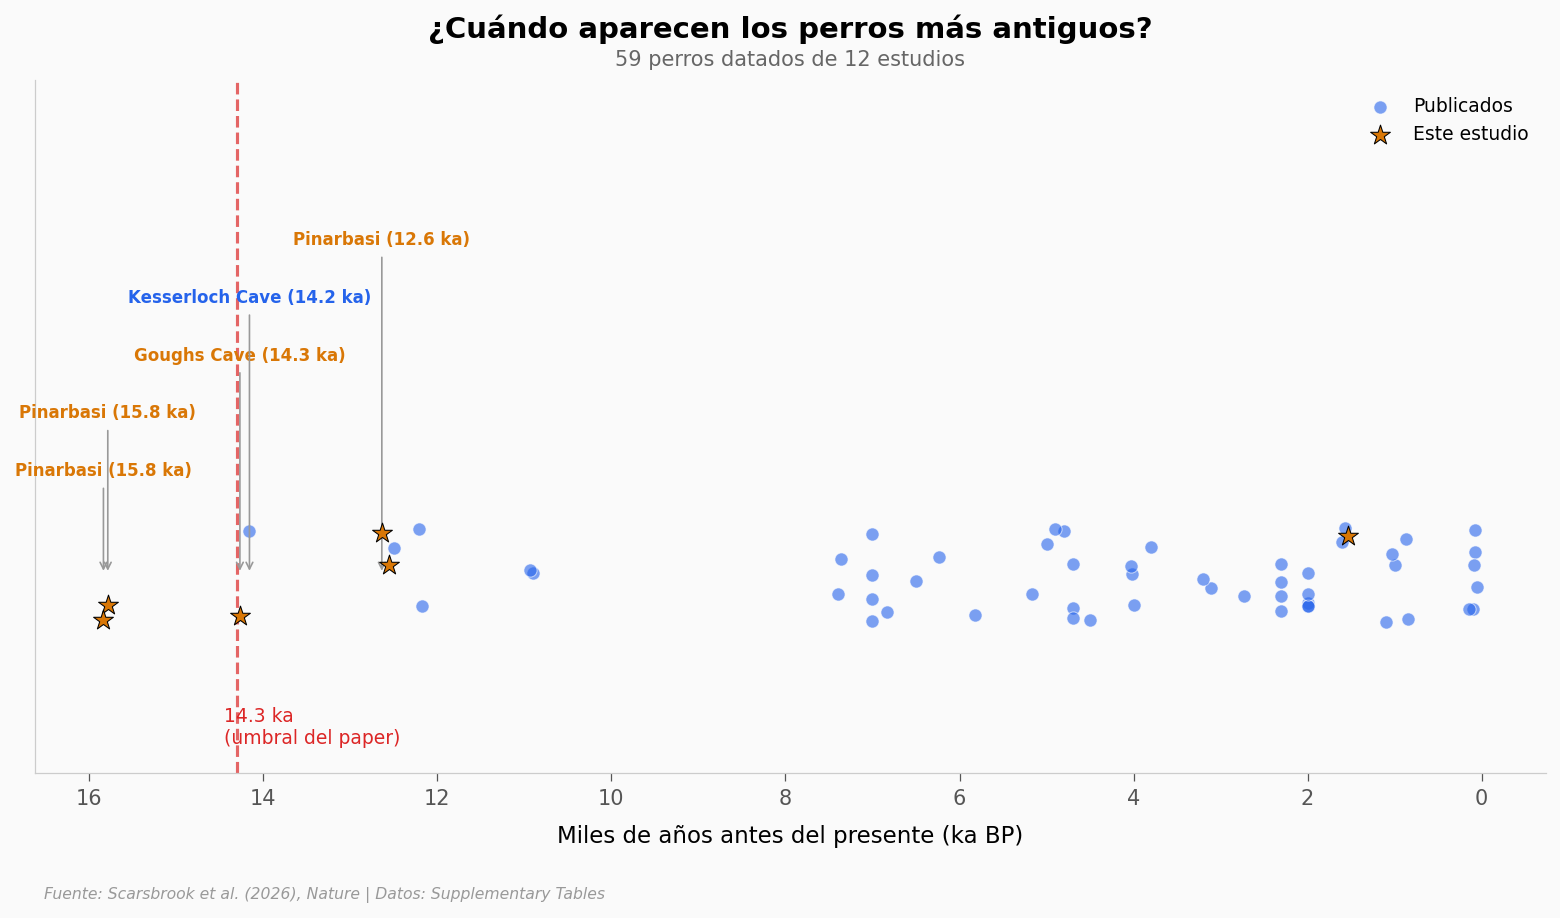

In [3]:
# Cronología: perros datados por sitio
dogs_crono = cronologia[cronologia['analysis_id'].str.startswith('D_', na=False)].copy()
dogs_dated = dogs_crono.dropna(subset=['date_mean_bp']).sort_values('date_mean_bp', ascending=True)

# Identificar nuevas muestras
dogs_dated['is_new'] = dogs_dated['paper'] == 'This study'

fig, ax = plt.subplots(figsize=(13, 6))

# Todos los perros datados
old = dogs_dated[~dogs_dated['is_new']]
new = dogs_dated[dogs_dated['is_new']]

np.random.seed(42)
y_old = np.random.uniform(-0.3, 0.3, len(old))
y_new = np.random.uniform(-0.3, 0.3, len(new))

ax.scatter(old['date_mean_bp'] / 1000, y_old, c=COLOR_PERRO, s=40, alpha=0.6,
           edgecolors='white', linewidths=0.5, zorder=3, label='Publicados')
ax.scatter(new['date_mean_bp'] / 1000, y_new, c=COLOR_NUEVO, s=100, marker='*',
           edgecolors='black', linewidths=0.5, zorder=5, label='Este estudio')

# Etiquetar los 5 más antiguos
top5 = dogs_dated.nlargest(5, 'date_mean_bp')
for i, (_, r) in enumerate(top5.iterrows()):
    site = r['site'].split(',')[0] if pd.notna(r['site']) else '?'
    y_pos = 0.6 + i * 0.35
    ax.annotate(f"{site} ({r['date_mean_bp']/1000:.1f} ka)",
                xy=(r['date_mean_bp']/1000, 0), xytext=(r['date_mean_bp']/1000, y_pos),
                fontsize=8, fontweight='bold', ha='center',
                color=COLOR_NUEVO if r['is_new'] else COLOR_PERRO,
                arrowprops=dict(arrowstyle='->', color='#999999', lw=0.8))

# Umbral 14,300 BP
ax.axvline(x=UMBRAL_ANTIGUO/1000, color=COLOR_LOBO, linewidth=1.5, linestyle='--', alpha=0.7)
ax.text(UMBRAL_ANTIGUO/1000 + 0.15, -0.8, f'{UMBRAL_ANTIGUO/1000:.1f} ka\n(umbral del paper)',
        fontsize=9, color=COLOR_LOBO, va='top')

ax.set_xlabel('Miles de años antes del presente (ka BP)', fontsize=11)
ax.set_yticks([])
ax.set_title('¿Cuándo aparecen los perros más antiguos?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, f'{len(dogs_dated)} perros datados de {dogs_dated["paper"].nunique()} estudios',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.legend(fontsize=9, loc='upper right', framealpha=0.9)
ax.invert_xaxis()
ax.set_ylim(-1.2, 3.0)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/cronologia_perros.png', dpi=200, bbox_inches='tight')
plt.show()

Tres de los cinco perros más antiguos vienen de Pınarbaşı (Turquía). Los otros dos: Gough's Cave (Inglaterra) y Kesserloch (Suiza). Ya para 14.000 años antes del presente, los perros se encontraban en al menos tres regiones separadas de Eurasia occidental.

## ¿Qué comían estos perros?

Los huesos guardan una firma química de lo que un animal comió en vida — los isótopos estables (δ¹³C y δ¹⁵N). El δ¹⁵N sube con el nivel trófico: cuanto más depredador, más alto. El δ¹³C delata la fuente vegetal de base (plantas C3 vs C4).

Solo tenemos datos isotópicos de 12 individuos de Gough's Cave y Pınarbaşı — pocos, pero reveladores.

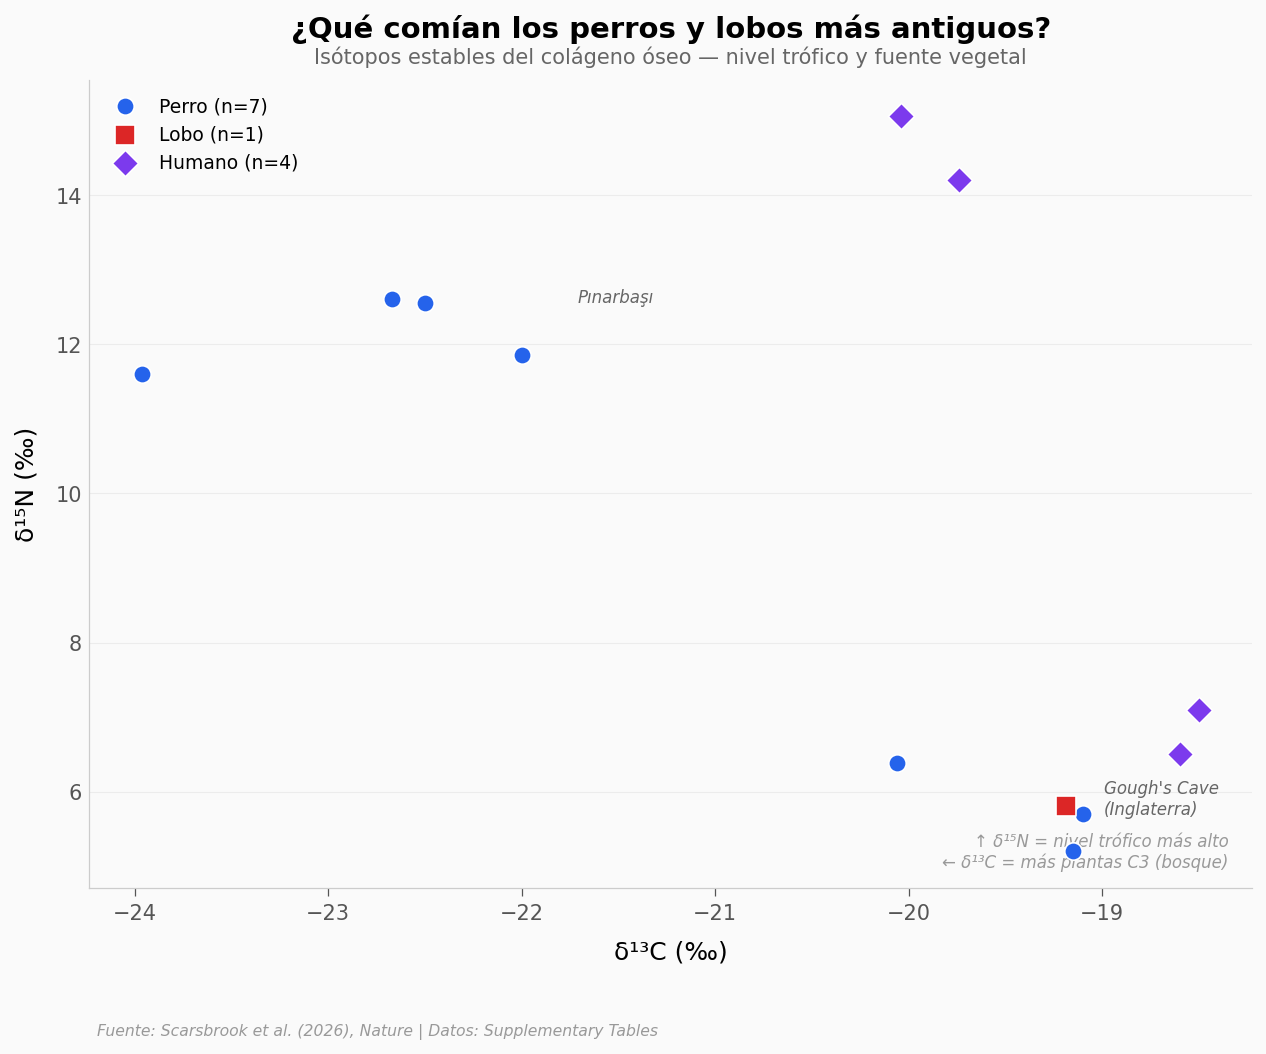

── Isótopos por especie ──
  Dog (n=7): δ¹³C = -21.3 ± 1.9‰, δ¹⁵N = 9.4 ± 3.5‰
  Wolf (n=1): δ¹³C = -19.2 ± nan‰, δ¹⁵N = 5.8 ± nan‰
  Human (n=4): δ¹³C = -19.2 ± 0.8‰, δ¹⁵N = 10.7 ± 4.5‰

⚠️ n demasiado bajo para tests estadísticos formales


In [4]:
fig, ax = plt.subplots(figsize=(10, 7))

species_config = {
    'Dog': (COLOR_PERRO, 'o', 70, 'Perro'),
    'Wolf': (COLOR_LOBO, 's', 90, 'Lobo'),
    'Human': (COLOR_HIGHLIGHT, 'D', 80, 'Humano'),
}

for sp, (color, marker, size, label) in species_config.items():
    sub = isotopos[isotopos['species'] == sp]
    if len(sub) > 0:
        ax.scatter(sub['d13c'], sub['d15n'], c=color, marker=marker, s=size,
                   edgecolors='white', linewidths=0.8, zorder=5, label=f'{label} (n={len(sub)})')

# Agrupar por sitio: elipses informales
for site in isotopos['site'].unique():
    sub = isotopos[isotopos['site'] == site]
    if len(sub) >= 2:
        cx, cy = sub['d13c'].mean(), sub['d15n'].mean()
        ax.annotate(site.replace("Gough's Cave", "Gough's Cave\n(Inglaterra)").replace(
                    "Pinarbasi", "Pınarbaşı\n(Turquía)"),
                    xy=(cx, cy), xytext=(10, -15), textcoords='offset points',
                    fontsize=8, color='#666666', style='italic')

ax.set_xlabel('δ¹³C (‰)', fontsize=12)
ax.set_ylabel('δ¹⁵N (‰)', fontsize=12)
ax.set_title('¿Qué comían los perros y lobos más antiguos?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, 'Isótopos estables del colágeno óseo — nivel trófico y fuente vegetal',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.legend(fontsize=9, loc='upper left', framealpha=0.9)

# Nota interpretativa
ax.text(0.98, 0.02, '↑ δ¹⁵N = nivel trófico más alto\n← δ¹³C = más plantas C3 (bosque)',
        transform=ax.transAxes, fontsize=8, color='#999999',
        ha='right', va='bottom', style='italic')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/isotopos_dieta.png', dpi=200, bbox_inches='tight')
plt.show()

# Estadísticas descriptivas (n muy bajo para tests formales)
print("── Isótopos por especie ──")
for sp in ['Dog', 'Wolf', 'Human']:
    sub = isotopos[isotopos['species'] == sp]
    if len(sub) > 0:
        print(f"  {sp} (n={len(sub)}): δ¹³C = {sub['d13c'].mean():.1f} ± {sub['d13c'].std():.1f}‰, "
              f"δ¹⁵N = {sub['d15n'].mean():.1f} ± {sub['d15n'].std():.1f}‰")
print("\n⚠️ n demasiado bajo para tests estadísticos formales")

Los perros de Gough's Cave (Inglaterra) y Pınarbaşı (Turquía) caen en la misma zona de la gráfica: su δ¹⁵N queda entre lobos y humanos. Los datos sugieren una dieta omnívora, coherente con un animal que ya vivía cerca de campamentos humanos pero aún cazaba por su cuenta.

⚠️ Solo 12 muestras isotópicas — estos patrones son indicios, no conclusiones.

## ¿Cuántos perros antiguos hay por período?

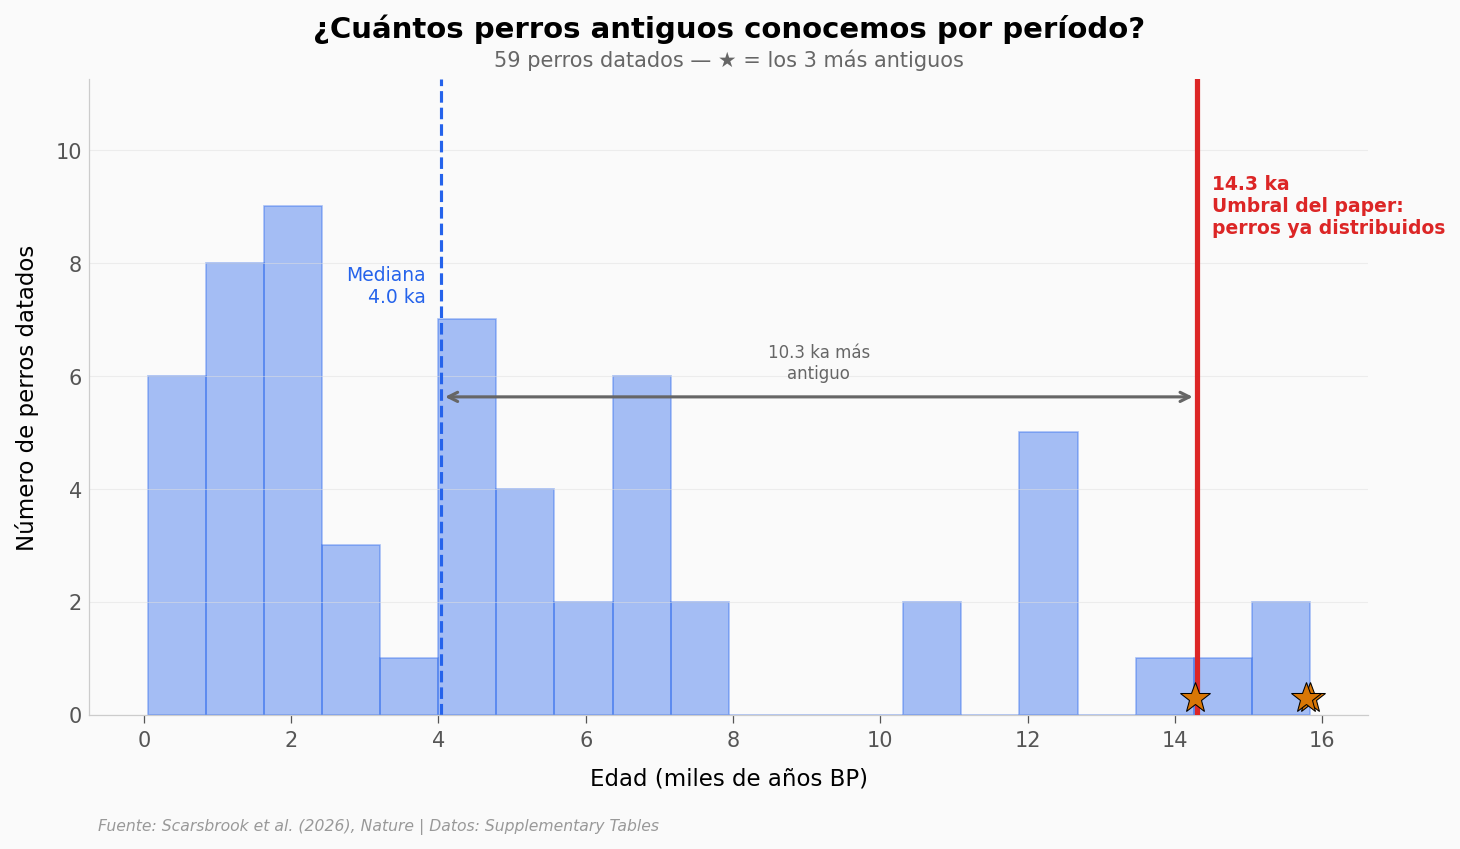


Perros con ≥14.3 ka: 2 de 59 (3%)
Mediana: 4.0 ka
Los más antiguos están 10.3 ka por encima de la mediana


In [5]:
# Distribución de edades de perros
dog_ages = dogs_dated['date_mean_bp'].values / 1000  # en ka

fig, ax = plt.subplots(figsize=(11, 5.5))

n, bins, patches = ax.hist(dog_ages, bins=20, color=COLOR_PERRO, alpha=0.4,
                           edgecolor=COLOR_PERRO, linewidth=0.8)
y_max = n.max() * 1.25
ax.set_ylim(0, y_max)

# Umbral 14.3 ka
ax.axvline(x=UMBRAL_ANTIGUO/1000, color=COLOR_LOBO, linewidth=2.5, zorder=5)
ax.text(UMBRAL_ANTIGUO/1000 + 0.2, y_max * 0.85,
        f'{UMBRAL_ANTIGUO/1000:.1f} ka\nUmbral del paper:\nperros ya distribuidos',
        fontsize=9, color=COLOR_LOBO, va='top', fontweight='bold')

# Mediana
median_age = np.median(dog_ages)
ax.axvline(x=median_age, color=COLOR_PERRO, linewidth=1.5, linestyle='--')
ax.text(median_age - 0.2, y_max * 0.65, f'Mediana\n{median_age:.1f} ka',
        fontsize=9, color=COLOR_PERRO, ha='right')

# Flecha bidireccional
ax.annotate('', xy=(UMBRAL_ANTIGUO/1000, y_max*0.5),
            xytext=(median_age, y_max*0.5),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
diff_ka = UMBRAL_ANTIGUO/1000 - median_age
ax.text((UMBRAL_ANTIGUO/1000 + median_age)/2, y_max*0.53,
        f'{diff_ka:.1f} ka más\nantiguo', fontsize=8, color='#666666', ha='center')

# Marcar los 3 perros más antiguos
for _, r in dogs_dated.nlargest(3, 'date_mean_bp').iterrows():
    ax.plot(r['date_mean_bp']/1000, 0.3, '*', color=COLOR_NUEVO,
            markersize=15, markeredgecolor='black', markeredgewidth=0.5, zorder=6)

ax.set_xlabel('Edad (miles de años BP)', fontsize=11)
ax.set_ylabel('Número de perros datados', fontsize=11)
ax.set_title('¿Cuántos perros antiguos conocemos por período?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, f'{len(dog_ages)} perros datados — ★ = los 3 más antiguos',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/distribucion_edades.png', dpi=200, bbox_inches='tight')
plt.show()

# Estadísticas
older_than_threshold = (dog_ages >= UMBRAL_ANTIGUO/1000).sum()
print(f"\nPerros con ≥{UMBRAL_ANTIGUO/1000:.1f} ka: {older_than_threshold} de {len(dog_ages)} ({100*older_than_threshold/len(dog_ages):.0f}%)")
print(f"Mediana: {median_age:.1f} ka")
print(f"Los más antiguos están {diff_ka:.1f} ka por encima de la mediana")

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| Perros genéticamente homogéneos distribuidos por Europa/Anatolia desde ≥14.300 BP | ✅ | Pınarbaşı (15.787 BP calibrado, Turquía) y Gough's Cave (14.269 BP, UK) separados por 3.188 km. Paper usa "indicate" — certeza moderada-alta |
| Tres culturas humanas distintas compartían los mismos perros | ⚠️ | Los sitios pertenecen a tradiciones distintas (Magdaleniense, Epigravettiano, cazadores-recolectores de Anatolia), pero la homogeneidad genética sale de los análisis genómicos, no de estas tablas |
| Influx de ancestría este-euroasiática en el Mesolítico | ⚠️ | 29 perros árticos en la muestra, pero la señal de mezcla la da el análisis genómico (PCA/admixture), no las tablas. Paper usa "identify" |
| Perros con dieta intermedia entre lobos y humanos | ⚠️ | Solo 12 muestras isotópicas (7 perros, 1 lobo, 4 humanos). Patrón consistente pero n insuficiente para test estadístico |

> **Limitaciones:** (1) Los datos tabulares no incluyen las proporciones de ancestría genómica — los análisis PCA y admixture están en las figuras del paper, no en los supplementary descargables. (2) Isotopes: n=12, insuficiente para conclusiones. (3) Las edades "c.11500-8300" son rangos estimados, no dataciones directas.

## Ahora tú

1. **¿Hay algún patrón geográfico en los grupos?** Los perros europeos, árticos y africanos/Cercano Oriente — ¿se solapan geográficamente o hay fronteras claras? Pista: filtra `dogs` por grupo y compara las distribuciones de latitud.

2. **¿Cuántos lobos son contemporáneos a los perros más antiguos?** Si filtras lobos con edad > 14.000 BP, ¿dónde vivían? ¿Se solapan con los perros?

3. **¿Qué tan antiguo es el registro genético vs el arqueológico?** El paper dice que la evidencia genética más temprana era ~10.900 BP antes de este estudio. Pınarbaşı empuja eso a 15.837 BP — ¿cuántos miles de años ganamos?

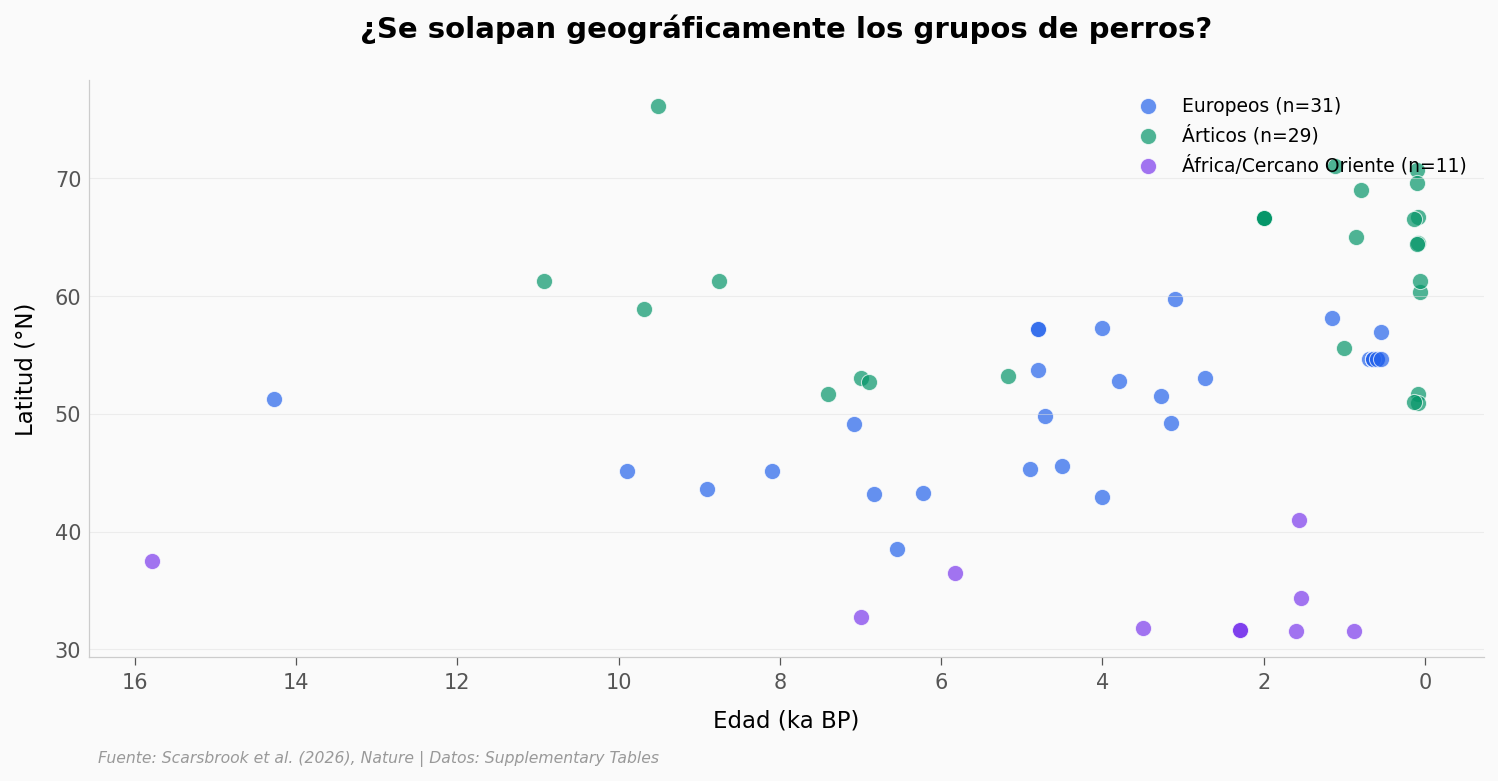

── Latitud por grupo ──
  European_Dogs: 38.5° – 59.7°N (med=53.0°N, n=31)
  Arctic_Dogs: 50.9° – 76.1°N (med=64.5°N, n=29)
  African_NearEast_India_Dogs: 31.6° – 41.0°N (med=31.9°N, n=11)


In [6]:
# --- EXPERIMENTA AQUÍ ---
# Pregunta: ¿Los perros europeos y árticos se solapan geográficamente?

fig, ax = plt.subplots(figsize=(12, 5))

for grp, color, label in [
    ('Ancient_European_Dogs', COLOR_PERRO, 'Europeos'),
    ('Ancient_Arctic_Dogs', COLOR_ARCTIC, 'Árticos'),
    ('Ancient_African_NearEast_India_Dogs', COLOR_HIGHLIGHT, 'África/Cercano Oriente'),
]:
    sub = dogs[dogs['group'] == grp].dropna(subset=['lat'])
    if len(sub) > 0:
        ax.scatter(sub['best_age'] / 1000, sub['lat'], c=color, s=60, alpha=0.7,
                   edgecolors='white', linewidths=0.5, label=f'{label} (n={len(sub)})')

ax.set_xlabel('Edad (ka BP)', fontsize=11)
ax.set_ylabel('Latitud (°N)', fontsize=11)
ax.set_title('¿Se solapan geográficamente los grupos de perros?',
             fontsize=14, fontweight='bold', pad=20)
ax.legend(fontsize=9, loc='upper right', framealpha=0.9)
ax.invert_xaxis()

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/grupos_latitud.png', dpi=200, bbox_inches='tight')
plt.show()

# Estadísticas por grupo
print("── Latitud por grupo ──")
for grp in ['Ancient_European_Dogs', 'Ancient_Arctic_Dogs', 'Ancient_African_NearEast_India_Dogs']:
    sub = dogs[dogs['group'] == grp].dropna(subset=['lat'])
    if len(sub) > 0:
        print(f"  {grp.replace('Ancient_', '')}: {sub['lat'].min():.1f}° – {sub['lat'].max():.1f}°N "
              f"(med={sub['lat'].median():.1f}°N, n={len(sub)})")

---

**Paper:** Scarsbrook, L. et al. (2026). "A genetically homogeneous dog population in the Late Upper Palaeolithic." *Nature*. DOI: [10.1038/s41586-026-10170-x](https://doi.org/10.1038/s41586-026-10170-x)

**Datos:** Supplementary Tables 1, 2, 5, 6 (descargados de Nature).

**Licencia datos:** CC-BY 4.0 (Nature Supplementary Materials).

**Repo:** [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab)